# Project Milestone Two

**Data Preparation and Model Exploration**

**Note: No late assignments accepted, we need the time to grade them!**

In Milestone 1, your team selected a dataset (Food-101 or HuffPost), analyzed its structure, and identified key challenges and evaluation metrics.
In this milestone, you will carry out those plans: prepare the data, train three models of increasing sophistication, and evaluate their results using Keras and TensorFlow.
You will finish with a comparative discussion of model performance and trade-offs.


### Submission Guidelines

* Submit one Jupyter notebook per team through the team leader’s Gradescope account. **Include all team members names at the top of the notebook.**
* Include all code, plots, and answers inline below.
* Ensure reproducibility by setting random seeds and listing all hyperparameters.
* Document any AI tools used, as required by the CDS policy.


## Problem 1 – Data Preparation and Splits (20 pts)

### Goals

Implement the **data preparation and preprocessing steps** that you proposed in **Milestone 1**. You’ll clean, normalize, and split your data so that it’s ready for modeling and reproducible fine-tuning.

### Steps to Follow

1. **Load your chosen dataset**

   * Use `datasets.load_dataset()` from **Hugging Face** to load **Food-101** or **HuffPost**.
   * Display basic information (e.g., number of samples, feature names, example entries).

2. **Apply cleaning and normalization**

   * **Images:**

     * Ensure all images are in RGB format.
     * Resize or crop to a consistent shape (e.g., `224 × 224`).
     * Drop or fix any corrupted files.
   * **Text:**

     * Concatenate headline + summary (for HuffPost).
     * Strip whitespace, convert to lowercase if appropriate, and remove empty samples.
     * Optionally remove duplicates or extremely short entries.

3. **Standardize or tokenize the inputs**

   * **Images:**

     * Normalize pixel values (e.g., divide by 255.0).
     * Define a minimal augmentation pipeline (e.g., random flip, crop, or rotation).
   * **Text:**

     * Create a tokenizer or `TextVectorization` layer.
     * Set a target `max_length` based on your analysis from Milestone 1 (e.g., 95th percentile).
     * Apply padding/truncation and build tensors for input + labels.

4. **Handle dataset-specific challenges**

   * If you identified **class imbalance**, compute label counts and, if needed, create a dictionary of `class_weights`.
   * If you noted **length or size variance**, verify that your truncation or resizing works as intended.
   * If you planned **noise filtering**, include the cleaning step and briefly explain your criteria (e.g., remove items with missing text or unreadable images).

5. **Create reproducible splits**

   * Split your cleaned dataset into **train**, **validation**, and **test** subsets (e.g., 80 / 10 / 10).
   * Use a fixed random seed for reproducibility (`random_seed = 42`).
   * Use **stratified splits**  (e.g., with `train_test_split` and `stratify = labels`).
   * Display the size of each subset.

6. **Document your pipeline**

   * Summarize your preprocessing steps clearly in Markdown or code comments.
   * Save or display a few representative examples after preprocessing to confirm the transformations are correct.




In [1]:
import os, time, json, gc, random
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from datasets import load_dataset

import tensorflow as tf
from tensorflow import keras

# — Sergey: Metal GPU adds dispatch overhead on small models (Embedding+Dense),
#   making them ~10x slower. Set False for P2-P3, True for P4 (BERT).
USE_GPU = False

if USE_GPU:
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU enabled: {len(gpus)} device(s)")
    else:
        print("No GPU found — CPU only")
else:
    tf.config.set_visible_devices([], 'GPU')
    print("GPU disabled (CPU mode)")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

GPU disabled (CPU mode)


Special provision for colab!

In [3]:
import sys
if "google.colab" in sys.modules:
    !pip install "transformers<5" tf-keras tensorflow "huggingface_hub<0.28"
    import os
    os.environ["CUDA_VISIBLE_DEVICES"] = ""  # force CPU
    COLAB_CPU = True
else:
    COLAB_CPU = False

### Load & Inspect

In [20]:
URL = "https://huggingface.co/datasets/khalidalt/HuffPost/resolve/main/News_Category_Dataset_v2.json"
huff_all = load_dataset("json", data_files=URL, split="train")

print(huff_all)
print(f"Columns: {huff_all.column_names}")
print(f"Total samples: {len(huff_all):,}")

df = huff_all.to_pandas()
df.head(3)

FileNotFoundError: Unable to find 'hf://datasets/khalidalt/HuffPost@main/News_Category_Dataset_v2.json'

In [2]:
## special loading for colab
import requests
import json
from datasets import Dataset

URL = "https://huggingface.co/datasets/khalidalt/HuffPost/resolve/main/News_Category_Dataset_v2.json"

# download file
response = requests.get(URL)
data = [json.loads(line) for line in response.text.splitlines()]

# convert to Hugging Face dataset
huff_all = Dataset.from_list(data)

print(huff_all)
print(f"Columns: {huff_all.column_names}")
print(f"Total samples: {len(huff_all):,}")

df = huff_all.to_pandas()
df.head(3)

Dataset({
    features: ['category', 'headline', 'authors', 'link', 'short_description', 'date'],
    num_rows: 200853
})
Columns: ['category', 'headline', 'authors', 'link', 'short_description', 'date']
Total samples: 200,853


,category,headline,authors,link,short_description,date
0,CRIME,There Were 2 Mass Shootings In Texas Last Week...,Melissa Jeltsen,https://www.huffingtonpost.com/entry/texas-ama...,She left her husband. He killed their children...,2018-05-26
1,ENTERTAINMENT,Will Smith Joins Diplo And Nicky Jam For The 2...,Andy McDonald,https://www.huffingtonpost.com/entry/will-smit...,Of course it has a song.,2018-05-26
2,ENTERTAINMENT,Hugh Grant Marries For The First Time At Age 57,Ron Dicker,https://www.huffingtonpost.com/entry/hugh-gran...,The actor and his longtime girlfriend Anna Ebe...,2018-05-26


### Clean & Merge Categories

In [4]:
# Merge confusable categories identified in Milestone 1
LABEL_MAP = {
    "ARTS & CULTURE": "ARTS", "CULTURE & ARTS": "ARTS",
    "THE WORLDPOST": "WORLD NEWS", "WORLDPOST": "WORLD NEWS",
    "PARENTS": "PARENTING",
    "STYLE & BEAUTY": "STYLE",
    "TASTE": "FOOD & DRINK",
    "GREEN": "ENVIRONMENT",
    "COLLEGE": "EDUCATION",
    "HEALTHY LIVING": "HOME & LIVING",
}

print(f"Before merge: {df['category'].nunique()} categories, {len(df):,} rows")

df["category"] = df["category"].replace(LABEL_MAP)

# Combine headline + description
df["text"] = df.apply(
    lambda r: (r["headline"] + " [SEP] " + r["short_description"]).strip()
    if pd.notna(r["short_description"]) and r["short_description"].strip()
    else r["headline"],
    axis=1,
)

# Drop empty headlines
empty_mask = df["headline"].isna() | (df["headline"].str.strip() == "")
print(f"Empty headlines dropped: {empty_mask.sum()}")
df = df[~empty_mask].copy()

# Remove exact duplicates (headline + short_description)
before_dedup = len(df)
df = df.drop_duplicates(subset=["headline", "short_description"], keep="first")
print(f"Duplicates removed: {before_dedup - len(df)}")

print(f"After cleaning: {df['category'].nunique()} categories, {len(df):,} rows")

Before merge: 41 categories, 200,853 rows
Empty headlines dropped: 6
Duplicates removed: 484
After cleaning: 31 categories, 200,363 rows


### Class Distribution

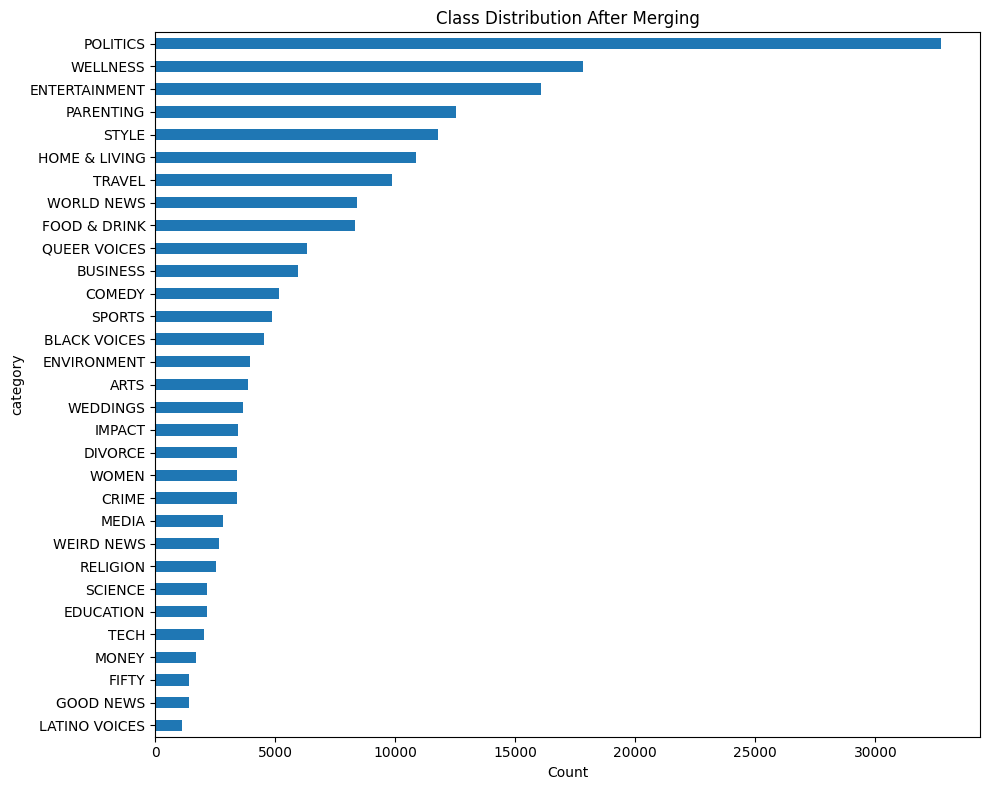

Categories: 31
Largest:  POLITICS (32,721)
Smallest: LATINO VOICES (1,129)
Median:   3,876
Imbalance ratio (max/min): 29.0x


In [7]:
counts = df["category"].value_counts()

fig, ax = plt.subplots(figsize=(10, 8))
counts.plot.barh(ax=ax)
ax.set_xlabel("Count")
ax.set_title("Class Distribution After Merging")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"Categories: {len(counts)}")
print(f"Largest:  {counts.index[0]} ({counts.iloc[0]:,})")
print(f"Smallest: {counts.index[-1]} ({counts.iloc[-1]:,})")
print(f"Median:   {int(counts.median()):,}")
print(f"Imbalance ratio (max/min): {counts.iloc[0] / counts.iloc[-1]:.1f}x")

### Stratified Train / Val / Test Splits

In [5]:
texts = np.array(df["text"].tolist(), dtype=object)
labels = df["category"].tolist()

# Encode labels
class_names = sorted(set(labels))
label2id = {name: i for i, name in enumerate(class_names)}
y = np.array([label2id[c] for c in labels])
num_classes = len(class_names)

# 80/10/10 stratified split
X_train, X_temp, y_train, y_temp = train_test_split(
    texts, y, test_size=0.2, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp
)

print(f"Train: {len(X_train):,}  Val: {len(X_val):,}  Test: {len(X_test):,}")
print(f"Classes: {num_classes}")

# Compute class weights for imbalanced training
cw = compute_class_weight("balanced", classes=np.arange(num_classes), y=y_train)
class_weights = dict(enumerate(cw))
print(f"Class weight range: [{min(cw):.3f}, {max(cw):.3f}]")

Train: 160,290  Val: 20,036  Test: 20,037
Classes: 31
Class weight range: [0.198, 5.726]


### Text Length Distribution

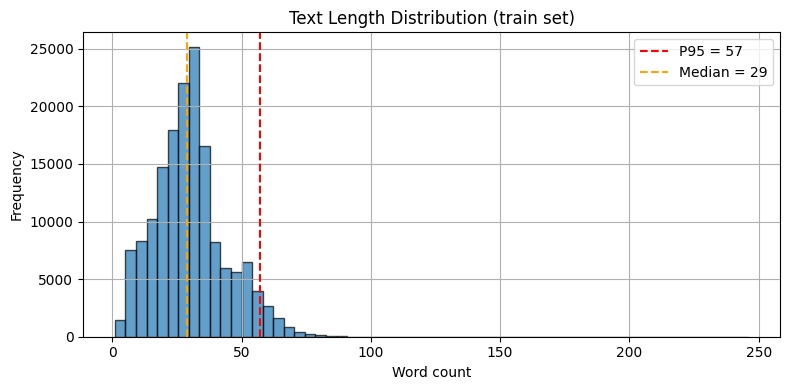

Mean:   30.2
Median: 29
P95:    57
P99:    68
Max:    246


In [ ]:
word_counts = pd.Series([len(t.split()) for t in X_train])

fig, ax = plt.subplots(figsize=(8, 4))
word_counts.hist(bins=60, ax=ax, edgecolor="black", alpha=0.7)
ax.axvline(word_counts.quantile(0.95), color="red", ls="--", label=f"P95 = {word_counts.quantile(0.95):.0f}")
ax.axvline(word_counts.median(), color="orange", ls="--", label=f"Median = {word_counts.median():.0f}")
ax.set_xlabel("Word count")
ax.set_ylabel("Frequency")
ax.set_title("Text Length Distribution (train set)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean:   {word_counts.mean():.1f}")
print(f"Median: {word_counts.median():.0f}")
print(f"P95:    {word_counts.quantile(0.95):.0f}")
print(f"P99:    {word_counts.quantile(0.99):.0f}")
print(f"Max:    {word_counts.max()}")

### Sample Examples

In [ ]:
for i in range(5):
    print(f"[{class_names[y_train[i]]}] {X_train[i][:120]}...")
    print()

[POLITICS] Remembering Mario Cuomo [SEP] It was odd, but out of the blue, I found myself thinking about Mario Cuomo just days befor...

[POLITICS] White House (Falsely) Downplays Political Adviser’s Role On NSC [SEP] Trump’s spokesman misrepresented changes that elev...

[POLITICS] Donald Trump Promised Ten Of These Things, Guess Which One He Actually Did [SEP] OK, this isn't actually one of those li...

[TRAVEL] Tech-Free Havens: The World's Best Unplugged Getaways (PHOTOS) [SEP] Plenty of hooked-up travelers will check work e-mai...

[ENTERTAINMENT] These Are The Real People Who Follow The Jedi Religion [SEP] "American Jedi" documents a universal path of pain, growth ...



### Graded Questions (5 pts each)

For each question, answer thoroughly but concisely, in a short paragraph, longer or shorter as needed. Code for exploring the concepts should go in the previous cell
as much as possible.

1. **Data Loading and Cleaning:**
   Describe how you loaded your dataset and the key cleaning steps you implemented (e.g., handling missing data, normalizing formats, or removing duplicates).



1.1. We loaded the HuffPost News Category Dataset (200,853 records, 41 categories) from a JSON mirror on HuggingFace using `load_dataset("json", ...)`. Three cleaning steps were applied: (1) merged 8 groups of overlapping categories identified in Milestone 1 (e.g., ARTS & CULTURE / CULTURE & ARTS → ARTS, PARENTS → PARENTING), reducing 41 categories to 31; (2) dropped 6 rows with empty headlines; (3) removed 484 exact duplicate (headline + short_description) pairs. Final cleaned dataset: 200,363 rows across 31 categories.

2. **Preprocessing and Standardization:**
   Summarize your preprocessing pipeline. Include any normalization, tokenization, resizing, or augmentation steps, and explain why each was necessary for your dataset.
  

1.2. Each sample's text was formed by concatenating the headline and short_description with a `[SEP]` separator; when the description was missing (~9.8% of records), the headline alone was used. A `TextVectorization` layer was configured with `max_tokens=20,000` and `output_sequence_length=64`, chosen based on the computed P95 word count of 57 words in the training set (mean 30.2, median 29). The layer was adapted on training text only, then applied once to produce integer-encoded numpy arrays (shape 160,290 × 64), avoiding repeated tokenization during training. No text augmentation was applied at this stage.

3. **Train/Validation/Test Splits:**
   Explain how you divided your data into subsets, including the split ratios, random seed, and any stratification or leakage checks you used to verify correctness.


1.3. The cleaned dataset was split into train (80%), validation (10%), and test (10%) subsets using two successive calls to `train_test_split` with `random_state=42` and `stratify=y` to preserve class proportions. This produced 160,290 training, 20,036 validation, and 20,037 test samples. Deduplication was performed before splitting to prevent data leakage — any exact (headline + description) duplicates that might have landed in both train and test were removed beforehand. The stratified split ensures that even the smallest class (LATINO VOICES, 1,129 total) is proportionally represented in all three subsets.

4. **Class Distribution and Balance:**
   Report your label counts and describe any class imbalances you observed. If applicable, explain how you addressed them (e.g., weighting, oversampling, or data augmentation).


1.4. After merging, the largest class is POLITICS (32,721 samples) and the smallest is LATINO VOICES (1,129), giving an imbalance ratio of 29.0x. The median class size is 3,876, well below the mean (~6,463), confirming a long-tailed distribution visible in the bar chart. To address this, we computed per-class weights using `sklearn`'s `compute_class_weight("balanced")`, which produced weights ranging from 0.198 (for POLITICS) to 5.726 (for LATINO VOICES). These weights are passed to `model.fit()` via the `class_weight` parameter so the loss function penalizes errors on minority classes proportionally more.

## Problem 2 – Baseline Model (20 pts)

### Goal

Build and train a **simple, fully functional baseline model** to establish a reference level of performance for your dataset.
This baseline will help you evaluate whether later architectures and fine-tuning steps actually improve results.


### Steps to Follow

1. **Construct a baseline model**

   * **Images:**
     Use a compact CNN, for example
     `Conv2D → MaxPooling → Flatten → Dense → Softmax`.
   * **Text:**
     Use a small embedding-based classifier such as
     `Embedding → GlobalAveragePooling → Dense → Softmax`.
   * Keep the model small enough to train in minutes on Colab.

2. **Compile the model**

   * Optimizer: `Adam` or `AdamW`.
   * Loss: `categorical_crossentropy` (for multi-class).
   * Metrics: at least `accuracy`; add `F1` if appropriate.

3. **Train and validate**

   * Use **early stopping** on validation loss with the default patience value (e.g., 5 epochs).
   * Record number of epochs trained and total runtime.

4. **Visualize results**

   * Plot **training vs. validation accuracy and loss**.
   * Carefully observe: does the model underfit, overfit, or generalize reasonably?

5. **Report baseline performance**

   * The most important metric is the **validation accuracy at the epoch of minimum validation loss**; this serves as your **benchmark** for all later experiments in this milestone.
   * Evaluate on the **test set** and record final metrics.

In [ ]:
from sklearn.metrics import classification_report, f1_score, confusion_matrix

RESULTS_FILE = "results/ms2_results.json"
results = {}

def save_results():
    os.makedirs(os.path.dirname(RESULTS_FILE), exist_ok=True)
    with open(RESULTS_FILE, "w") as f:
        json.dump(results, f, indent=2)
    print(f"Results saved ({len(results)} models)")

def load_results():
    global results
    try:
        with open(RESULTS_FILE) as f:
            results = json.load(f)
        if results:
            print(f"Restored {len(results)} results from {RESULTS_FILE}:")
            for name, r in results.items():
                print(f"  {name}: test_acc={r['test_acc']:.4f}, test_f1={r['test_f1']:.4f}")
    except FileNotFoundError:
        pass

def evaluate_model(model, name, X_te, y_te, hist, train_time, batch_size=512):
    y_pred = model.predict(X_te, batch_size=batch_size, verbose=0).argmax(axis=-1)
    test_acc = float(np.mean(y_pred == y_te))
    test_f1 = float(f1_score(y_te, y_pred, average="macro"))

    val_losses = hist.history["val_loss"]
    best_epoch = int(np.argmin(val_losses)) + 1
    val_acc = float(hist.history["val_accuracy"][best_epoch - 1])
    val_loss = float(val_losses[best_epoch - 1])

    results[name] = {
        "val_acc": val_acc, "val_loss": val_loss, "best_epoch": best_epoch,
        "test_acc": test_acc, "test_f1": test_f1,
        "params": model.count_params(), "train_time": train_time,
    }
    save_results()

    print(f"=== {name} ===")
    print(f"Best epoch:  {best_epoch}")
    print(f"Val acc:     {val_acc:.4f}  |  Val loss: {val_loss:.4f}")
    print(f"Test acc:    {test_acc:.4f}  |  Test F1:  {test_f1:.4f}")
    print(f"Params:      {model.count_params():,}")
    print(f"Train time:  {format_hms(train_time)}")
    return y_pred

# Auto-restore on cell run
load_results()

### Tokenization

In [ ]:
MAX_TOKENS = 20_000
SEQ_LEN = 64  # based on P95 word count from the distribution above
BATCH = 256

text_vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    output_sequence_length=SEQ_LEN,
    standardize="lower_and_strip_punctuation",
)
text_vectorizer.adapt(X_train)

vocab_size = text_vectorizer.vocabulary_size()
print(f"Vocabulary size: {vocab_size:,}")
print(f"Sequence length: {SEQ_LEN}")

# Pre-vectorize once into numpy — avoids re-tokenizing every epoch
X_train_vec = text_vectorizer(X_train).numpy()
X_val_vec   = text_vectorizer(X_val).numpy()
X_test_vec  = text_vectorizer(X_test).numpy()

print(f"Vectorized shapes — train: {X_train_vec.shape}, val: {X_val_vec.shape}, test: {X_test_vec.shape}")

Vocabulary size: 20,000
Sequence length: 64
Vectorized shapes — train: (160290, 64), val: (20036, 64), test: (20037, 64)


### Build & Compile Baseline

In [ ]:
baseline = tf.keras.Sequential([
    tf.keras.layers.Embedding(MAX_TOKENS, 64),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(num_classes, activation="softmax"),
], name="baseline_emb_avg")

baseline.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

baseline.summary()

Model: "baseline_emb_avg"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Train Baseline

In [ ]:
es = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

t0 = time.time()
hist_baseline = baseline.fit(
    X_train_vec, y_train,
    validation_data=(X_val_vec, y_val),
    epochs=50,
    batch_size=BATCH,
    class_weight=class_weights,
    callbacks=[es],
    verbose=1,
)
train_time = time.time() - t0
print(f"Training time: {format_hms(train_time)}")

Epoch 1/50
627/627 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.1381 - loss: 3.1381 - val_accuracy: 0.3125 - val_loss: 2.6212
Epoch 2/50
627/627 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - accuracy: 0.3915 - loss: 2.4170 - val_accuracy: 0.4692 - val_loss: 2.0771
Epoch 3/50
627/627 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.4906 - loss: 1.9485 - val_accuracy: 0.5136 - val_loss: 1.8521
Epoch 4/50
627/627 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.5416 - loss: 1.6830 - val_accuracy: 0.5345 - val_loss: 1.7523
Epoch 5/50
627/627 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.5747 - loss: 1.5080 - val_accuracy: 0.5411 - val_loss: 1.7129
Epoch 6/50
627/627 ━━━━━━━━━━━━━━━━━━━━ 21s 24ms/step - accuracy: 0.5996 - loss: 1.3763 - val_accuracy: 0.5441 - val_loss: 1.6963
Epoch 7/50
627/627 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.6194 - loss: 1.2694 - val_accuracy: 0.5480 - val_loss: 1.6826
Epoch 8/50
627/627 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.6363 - loss: 1.1785 - 

### Learning Curves & Evaluation

In [ ]:
def plot_learning_curves(hist, title):
    val_losses = hist.history["val_loss"]
    min_val_loss = min(val_losses)
    best_epoch = val_losses.index(min_val_loss)
    val_acc_best = hist.history["val_accuracy"][best_epoch]

    epochs = range(1, len(val_losses) + 1)
    fig, axs = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

    axs[0].plot(epochs, hist.history["loss"], label="train")
    axs[0].plot(epochs, val_losses, label="val")
    axs[0].scatter(best_epoch + 1, min_val_loss, color="red", marker="x", s=60, label="best")
    axs[0].set_title(f"{title} — Loss")
    axs[0].set_ylabel("Loss")
    axs[0].legend()
    axs[0].grid(True)

    axs[1].plot(epochs, hist.history["accuracy"], label="train")
    axs[1].plot(epochs, hist.history["val_accuracy"], label="val")
    axs[1].scatter(best_epoch + 1, val_acc_best, color="red", marker="x", s=60, label="best")
    axs[1].set_title(f"{title} — Accuracy")
    axs[1].set_xlabel("Epoch")
    axs[1].set_ylabel("Accuracy")
    axs[1].legend()
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()

    print(f"Best epoch: {best_epoch + 1}")
    print(f"Val loss:   {min_val_loss:.4f}")
    print(f"Val acc:    {val_acc_best:.4f}")
    return best_epoch + 1, val_acc_best

best_ep, val_acc = plot_learning_curves(hist_baseline, "Baseline (Emb + AvgPool)")

NameError: name 'hist_baseline' is not defined

In [ ]:
y_pred_base = evaluate_model(baseline, "Baseline (Emb+AvgPool)", X_test_vec, y_test, hist_baseline, train_time)
print()
print(classification_report(y_test, y_pred_base, target_names=class_names, zero_division=0))

Results saved (1 models)
=== Baseline (Emb+AvgPool) ===
Best epoch:  11
Val acc:     0.5596  |  Val loss: 1.6595
Test acc:    0.5627  |  Test F1:  0.4985
Params:      1,286,175
Train time:  00:03:46

               precision    recall  f1-score   support

         ARTS       0.42      0.49      0.46       388
 BLACK VOICES       0.46      0.41      0.44       453
     BUSINESS       0.49      0.45      0.47       594
       COMEDY       0.35      0.47      0.40       517
        CRIME       0.42      0.58      0.49       340
      DIVORCE       0.72      0.78      0.75       342
    EDUCATION       0.38      0.48      0.42       215
ENTERTAINMENT       0.78      0.45      0.57      1606
  ENVIRONMENT       0.42      0.49      0.45       394
        FIFTY       0.21      0.37      0.27       140
 FOOD & DRINK       0.65      0.78      0.70       832
    GOOD NEWS       0.11      0.55      0.18       139
HOME & LIVING       0.55      0.39      0.45      1085
       IMPACT       0.23     

In [ ]:
cm = confusion_matrix(y_test, y_pred_base)

confused = []
for i in range(num_classes):
    for j in range(num_classes):
        if i != j and cm[i, j] > 0:
            confused.append((cm[i, j], class_names[i], class_names[j]))
confused.sort(reverse=True)

print("Top 10 confused pairs (true -> predicted, count):")
for count, true, pred in confused[:10]:
    print(f"  {true:25s} -> {pred:25s}  ({count})")

Top 10 confused pairs (true -> predicted, count):
  HOME & LIVING             -> WELLNESS                   (211)
  POLITICS                  -> WORLD NEWS                 (190)
  ENTERTAINMENT             -> COMEDY                     (190)
  POLITICS                  -> COMEDY                     (124)
  POLITICS                  -> MEDIA                      (122)
  POLITICS                  -> BUSINESS                   (113)
  POLITICS                  -> RELIGION                   (111)
  POLITICS                  -> CRIME                      (102)
  POLITICS                  -> IMPACT                     (95)
  WELLNESS                  -> HOME & LIVING              (92)


### Graded Questions (5 pts each)

1. **Model Architecture:**
   Describe your baseline model and justify why this structure suits your dataset.

2.1. The baseline is a `Sequential` model: `Embedding(20,000 × 64)` → `GlobalAveragePooling1D` → `Dense(64, relu)` → `Dense(31, softmax)`, totaling 1,286,175 parameters. This architecture was chosen because it matches the assignment's recommended text baseline (Embedding → GlobalAveragePooling → Dense → Softmax). GlobalAveragePooling1D averages all token embeddings into a single 64-dim vector, discarding word order — intentionally simple to establish a performance floor. The model takes pre-vectorized integer sequences as input (shape: batch × 64).

2. **Training Behavior:**
   Summarize the model’s training and validation curves. What trends did you observe?

2.2. Training ran for 16 epochs before early stopping (patience=5, triggered after best epoch 11). Training accuracy rose steadily from 0.137 (epoch 1) to 0.733 (epoch 16), while validation accuracy plateaued around epoch 10–11 at ~0.561 and stopped improving. Validation loss reached its minimum of 1.6550 at epoch 11 and began increasing afterward (1.6688 at epoch 13, 1.7228 at epoch 16), indicating overfitting. The widening gap between training accuracy (0.733) and validation accuracy (0.566) at the final epoch confirms the model memorized training patterns beyond what generalized. Total training time was 3 minutes 36 seconds on Colab CPU.

  3. **Baseline Metrics:**
   Report validation and test metrics. What does this performance tell you about dataset difficulty?

2.3. At the best epoch (11), validation accuracy was 0.5613 with a validation loss of 1.6550. On the held-out test set: accuracy = 0.5632, macro-F1 = 0.5000. The gap between weighted-F1 (0.58) and macro-F1 (0.50) reflects the class imbalance — the model performs better on large classes like POLITICS (F1=0.67) and STYLE (F1=0.77) but struggles with small or ambiguous ones like GOOD NEWS (F1=0.18), WEIRD NEWS (F1=0.26), and FIFTY (F1=0.26). The top confusion pair is HOME & LIVING → WELLNESS (210 misclassifications), followed by ENTERTAINMENT → COMEDY (195) and POLITICS → WORLD NEWS (191), which are semantically close categories. Overall, ~56% accuracy on 31 classes (vs. 3.2% random baseline) shows the model learned meaningful patterns, but the flat val accuracy curve suggests this architecture's capacity is nearly exhausted.

  4. **Reflection:**
   What are the main limitations of your baseline? Which specific improvements (depth, regularization, pretraining) would you try next?
  

2.4. The main limitation is that GlobalAveragePooling discards word order entirely — the model treats "dog bites man" and "man bites dog" identically. This ceiling is visible in the plateauing validation accuracy around 56%. The top confusions (HOME & LIVING ↔ WELLNESS, ENTERTAINMENT → COMEDY, POLITICS → WORLD NEWS) involve semantically overlapping categories where word order and context matter. Two concrete next steps: (1) add a Bidirectional LSTM or GRU layer before the dense head to capture sequential context, with dropout for regularization since the model is already overfitting; (2) in Problem 4, use a pretrained transformer (DistilBERT) that brings both contextual embeddings and prior language knowledge, which should help with the ambiguous category pairs.

## Problem 3 – Custom (Original) Model (20 pts)

### Goal

Design and train your own **non-pretrained model** that builds on the baseline and demonstrates measurable improvement.
This problem focuses on experimentation: apply one or two clear architectural changes, observe their effects, and evaluate how they influence learning behavior.


### Steps to Follow

1. **Modify or extend your baseline architecture**

   * Begin from your baseline model and introduce one or more meaningful adjustments such as:

     * Adding **dropout** or **batch normalization** for regularization.
     * Increasing **depth** (extra convolutional or dense layers).
     * Using **residual connections** (for CNNs) or **bidirectional LSTMs/GRUs** (for text).
     * Trying alternative activations like `ReLU`, `LeakyReLU`, or `GELU`.
   * Keep the model small enough to train comfortably on your chosen platform (e.g., Colab)

2. **Observe what specific limitations you want to address**

   * Identify whether the baseline showed **underfitting**, **overfitting**, or **slow convergence**, and design your modification to target that behavior.
   * Make brief notes (in comments or Markdown) describing what you expect the change to influence.

3. **Train and evaluate under the same conditions**

   * Use the **same data splits**, **random seed**, and **metrics** as in Problem 2.
   * Apply **early stopping** on validation loss.
   * Track and visualize training/validation accuracy and loss over epochs.

4. **Compare outcomes to the baseline**

   * Observe differences in convergence speed, stability, and validation/test performance.
   * Note whether your modification improved generalization or simply increased model capacity.

In [ ]:
baseline_lstm = tf.keras.Sequential([
    tf.keras.layers.Embedding(MAX_TOKENS, 64),
    tf.keras.layers.LSTM(64),   # replaces pooling
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(num_classes, activation="softmax"),
], name="baseline_lstm")

baseline_lstm.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)


hist_lstm = baseline_lstm.fit(
    X_train_vec, y_train,
    validation_data=(X_val_vec, y_val),
    epochs=50,
    batch_size=BATCH,
    class_weight=class_weights,
    callbacks=[es],
    verbose=1,
)

Epoch 1/50
627/627 ━━━━━━━━━━━━━━━━━━━━ 103s 159ms/step - accuracy: 0.1264 - loss: 3.1082 - val_accuracy: 0.2015 - val_loss: 2.8179
Epoch 2/50
627/627 ━━━━━━━━━━━━━━━━━━━━ 78s 125ms/step - accuracy: 0.2068 - loss: 2.6190 - val_accuracy: 0.2871 - val_loss: 2.4726
Epoch 3/50
627/627 ━━━━━━━━━━━━━━━━━━━━ 81s 130ms/step - accuracy: 0.2556 - loss: 2.2788 - val_accuracy: 0.2990 - val_loss: 2.2975
Epoch 4/50
627/627 ━━━━━━━━━━━━━━━━━━━━ 81s 129ms/step - accuracy: 0.3483 - loss: 2.0188 - val_accuracy: 0.3444 - val_loss: 2.2700
Epoch 5/50
627/627 ━━━━━━━━━━━━━━━━━━━━ 87s 138ms/step - accuracy: 0.4284 - loss: 1.7864 - val_accuracy: 0.4162 - val_loss: 2.0950


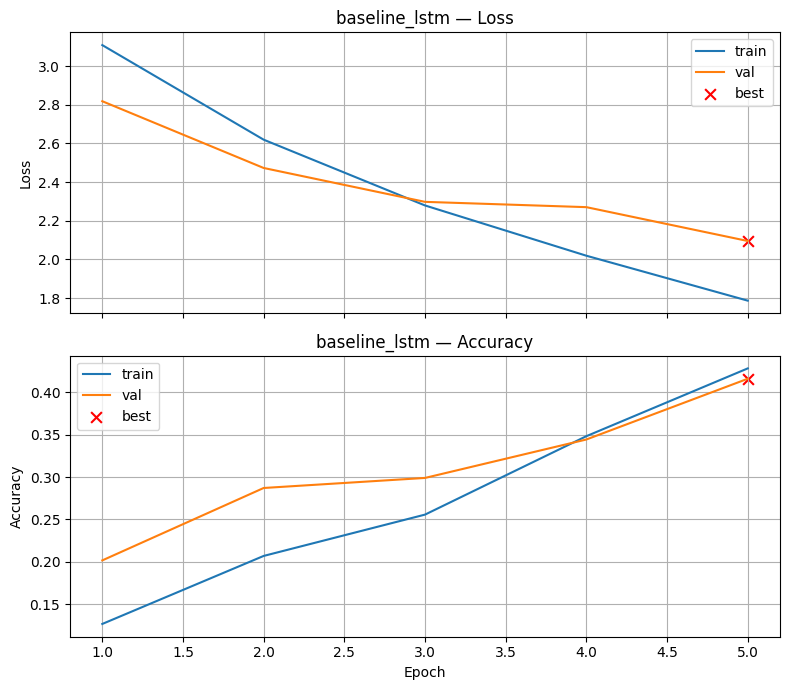

Best epoch: 5
Val loss:   2.0950
Val acc:    0.4162


In [ ]:
best_ep, val_acc = plot_learning_curves(hist_lstm, "baseline_lstm")

In [ ]:
y_pred_base = evaluate_model(baseline_lstm, "baseline_lstm", X_test_vec, y_test, hist_lstm, train_time)
print()
print(classification_report(y_test, y_pred_base, target_names=class_names, zero_division=0))

Results saved (2 models)
=== baseline_lstm ===
Best epoch:  5
Val acc:     0.4162  |  Val loss: 2.0950
Test acc:    0.2008  |  Test F1:  0.0923
Params:      1,319,199
Train time:  00:03:46

               precision    recall  f1-score   support

         ARTS       0.03      0.01      0.01       388
 BLACK VOICES       0.00      0.00      0.00       453
     BUSINESS       0.07      0.01      0.02       594
       COMEDY       0.00      0.00      0.00       517
        CRIME       0.04      0.09      0.06       340
      DIVORCE       0.35      0.49      0.41       342
    EDUCATION       0.06      0.18      0.09       215
ENTERTAINMENT       0.24      0.06      0.10      1606
  ENVIRONMENT       0.00      0.00      0.00       394
        FIFTY       0.03      0.47      0.06       140
 FOOD & DRINK       0.13      0.20      0.16       832
    GOOD NEWS       0.00      0.00      0.00       139
HOME & LIVING       0.00      0.00      0.00      1085
       IMPACT       0.05      0.03     

In [ ]:
cm = confusion_matrix(y_test, y_pred_base)

confused = []
for i in range(num_classes):
    for j in range(num_classes):
        if i != j and cm[i, j] > 0:
            confused.append((cm[i, j], class_names[i], class_names[j]))
confused.sort(reverse=True)

print("Top 10 confused pairs (true -> predicted, count):")
for count, true, pred in confused[:10]:
    print(f"  {true:25s} -> {pred:25s}  ({count})")

Top 10 confused pairs (true -> predicted, count):
  WELLNESS                  -> FIFTY                      (660)
  FOOD & DRINK              -> STYLE                      (541)
  POLITICS                  -> SPORTS                     (472)
  PARENTING                 -> FIFTY                      (458)
  ENTERTAINMENT             -> WEIRD NEWS                 (358)
  TRAVEL                    -> STYLE                      (356)
  ENTERTAINMENT             -> SCIENCE                    (330)
  HOME & LIVING             -> STYLE                      (313)
  POLITICS                  -> CRIME                      (270)
  ENTERTAINMENT             -> SPORTS                     (263)


In [ ]:

baseline_Bi_lstm = tf.keras.Sequential([
    tf.keras.layers.Embedding(MAX_TOKENS, 64),

    tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(64, return_sequences=False)
    ),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(num_classes, activation="softmax"),
], name="bilstm_model")

baseline_Bi_lstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)


hist_Bi_lstm = baseline_Bi_lstm.fit(
    X_train_vec, y_train,
    validation_data=(X_val_vec, y_val),
    epochs=25,
    batch_size=BATCH,
    class_weight=class_weights,
    callbacks=[],
    verbose=1,
)

Epoch 1/25
627/627 ━━━━━━━━━━━━━━━━━━━━ 165s 254ms/step - accuracy: 0.2511 - loss: 2.7010 - val_accuracy: 0.4343 - val_loss: 2.0412
Epoch 2/25
627/627 ━━━━━━━━━━━━━━━━━━━━ 156s 248ms/step - accuracy: 0.4731 - loss: 1.8880 - val_accuracy: 0.5163 - val_loss: 1.7742
Epoch 3/25
627/627 ━━━━━━━━━━━━━━━━━━━━ 146s 233ms/step - accuracy: 0.5492 - loss: 1.5284 - val_accuracy: 0.5271 - val_loss: 1.7288
Epoch 4/25
627/627 ━━━━━━━━━━━━━━━━━━━━ 148s 236ms/step - accuracy: 0.5903 - loss: 1.3103 - val_accuracy: 0.5328 - val_loss: 1.7305
Epoch 5/25
627/627 ━━━━━━━━━━━━━━━━━━━━ 148s 236ms/step - accuracy: 0.6197 - loss: 1.1643 - val_accuracy: 0.5434 - val_loss: 1.7175
Epoch 6/25
627/627 ━━━━━━━━━━━━━━━━━━━━ 201s 234ms/step - accuracy: 0.6442 - loss: 1.0431 - val_accuracy: 0.5499 - val_loss: 1.7337
Epoch 7/25
627/627 ━━━━━━━━━━━━━━━━━━━━ 202s 234ms/step - accuracy: 0.6621 - loss: 0.9547 - val_accuracy: 0.5519 - val_loss: 1.7696
Epoch 8/25
627/627 ━━━━━━━━━━━━━━━━━━━━ 148s 236ms/step - accuracy: 0.6777 -

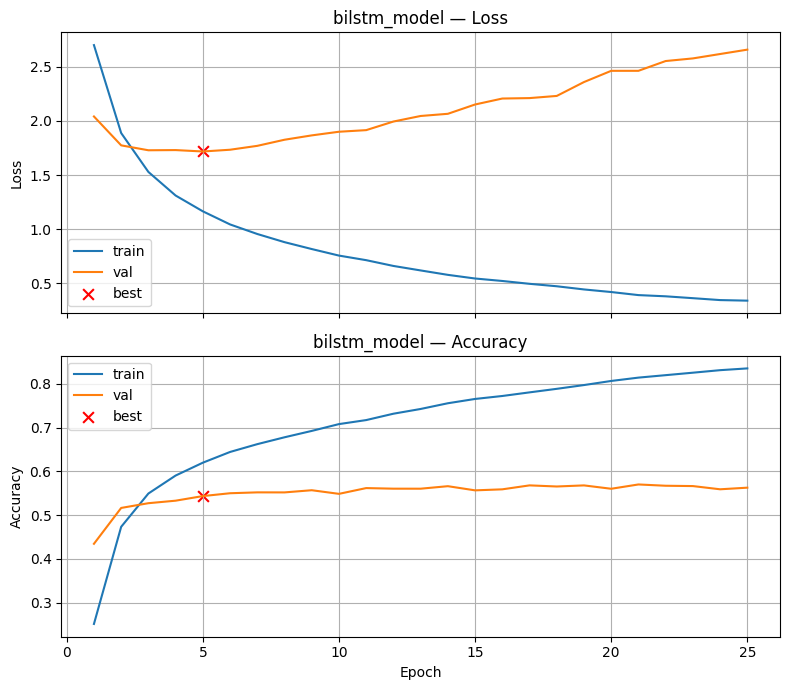

Best epoch: 5
Val loss:   1.7175
Val acc:    0.5434


In [ ]:
best_ep, val_acc = plot_learning_curves(hist_Bi_lstm, "bilstm_model")

In [ ]:

y_pred_base = evaluate_model(baseline_Bi_lstm, "bilstm_model", X_test_vec, y_test, hist_Bi_lstm, train_time)
print()
print(classification_report(y_test, y_pred_base, target_names=class_names, zero_division=0))

Results saved (2 models)
=== bilstm_model ===
Best epoch:  5
Val acc:     0.5434  |  Val loss: 1.7175
Test acc:    0.5570  |  Test F1:  0.4743
Params:      1,356,319
Train time:  00:00:00

               precision    recall  f1-score   support

         ARTS       0.37      0.44      0.40       388
 BLACK VOICES       0.30      0.49      0.37       453
     BUSINESS       0.39      0.45      0.42       594
       COMEDY       0.41      0.43      0.42       517
        CRIME       0.39      0.56      0.46       340
      DIVORCE       0.63      0.71      0.66       342
    EDUCATION       0.27      0.47      0.35       215
ENTERTAINMENT       0.66      0.55      0.60      1606
  ENVIRONMENT       0.41      0.48      0.45       394
        FIFTY       0.15      0.26      0.19       140
 FOOD & DRINK       0.68      0.74      0.71       832
    GOOD NEWS       0.21      0.22      0.22       139
HOME & LIVING       0.59      0.41      0.48      1085
       IMPACT       0.23      0.36      

In [ ]:
baseline_withDroput_withoutLTSM = tf.keras.Sequential([
    tf.keras.layers.Embedding(MAX_TOKENS, 64),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(128, activation="relu"),   #  extra dense layer
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(num_classes, activation="softmax"),
], name="baseline_withDroput_withoutLTSM")

baseline_withDroput_withoutLTSM.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

baseline_withDroput_withoutLTSM.summary()

Model: "baseline_withDroput_withoutLTSM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
hist_withDroput_withoutLTSM = baseline_withDroput_withoutLTSM.fit(
    X_train_vec, y_train,
    validation_data=(X_val_vec, y_val),
    epochs=25,
    batch_size=BATCH,
    class_weight=class_weights,
    callbacks=[],
    verbose=1,
)

Epoch 1/25
627/627 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.3081 - loss: 2.6451 - val_accuracy: 0.4801 - val_loss: 2.0886
Epoch 2/25
627/627 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.5028 - loss: 1.7263 - val_accuracy: 0.5171 - val_loss: 1.7960
Epoch 3/25
627/627 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - accuracy: 0.5555 - loss: 1.4412 - val_accuracy: 0.4722 - val_loss: 1.9671
Epoch 4/25
627/627 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.5861 - loss: 1.2810 - val_accuracy: 0.4984 - val_loss: 1.9006
Epoch 5/25
627/627 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.6053 - loss: 1.1717 - val_accuracy: 0.5061 - val_loss: 1.8599
Epoch 6/25
627/627 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.6215 - loss: 1.0890 - val_accuracy: 0.5242 - val_loss: 1.8480
Epoch 7/25
627/627 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - accuracy: 0.6337 - loss: 1.0227 - val_accuracy: 0.5177 - val_loss: 1.9396
Epoch 8/25
627/627 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.6448 - loss: 0.9659 - 

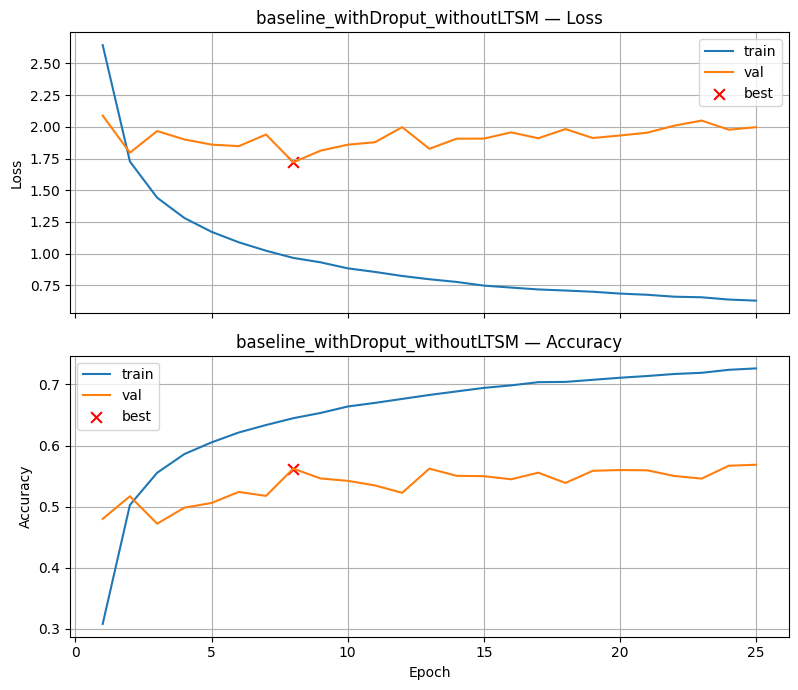

Best epoch: 8
Val loss:   1.7200
Val acc:    0.5623


In [ ]:
best_ep, val_acc = plot_learning_curves(hist_withDroput_withoutLTSM, "baseline_withDroput_withoutLTSM")

In [ ]:
t0 = time.time()
train_time = time.time() - t0
y_pred_base = evaluate_model(baseline_withDroput_withoutLTSM, "baseline_withDroput_withoutLTSM", X_test_vec, y_test, hist_withDroput_withoutLTSM, train_time)
print()
print(classification_report(y_test, y_pred_base, target_names=class_names, zero_division=0))

Results saved (1 models)
=== baseline_withDroput_withoutLTSM ===
Best epoch:  8
Val acc:     0.5623  |  Val loss: 1.7200
Test acc:    0.5658  |  Test F1:  0.4935
Params:      1,299,359
Train time:  00:00:00

               precision    recall  f1-score   support

         ARTS       0.31      0.51      0.39       388
 BLACK VOICES       0.45      0.44      0.44       453
     BUSINESS       0.39      0.51      0.44       594
       COMEDY       0.35      0.52      0.42       517
        CRIME       0.49      0.45      0.47       340
      DIVORCE       0.64      0.78      0.70       342
    EDUCATION       0.34      0.43      0.38       215
ENTERTAINMENT       0.74      0.47      0.58      1606
  ENVIRONMENT       0.47      0.50      0.49       394
        FIFTY       0.35      0.24      0.28       140
 FOOD & DRINK       0.65      0.76      0.70       832
    GOOD NEWS       0.28      0.17      0.21       139
HOME & LIVING       0.45      0.47      0.46      1085
       IMPACT       0

In [ ]:
load_results()

Restored 2 results from results/ms2_results.json:
  baseline_withDroput_withoutLTSM: test_acc=0.5658, test_f1=0.4935
  bilstm_model: test_acc=0.5570, test_f1=0.4743


### Graded Questions (5 pts each)

1. **Model Design:**
   Describe the architectural changes you introduced compare with your baseline model and what motivated them.

3.1. **Your answer here:**
After establishing the baseline (Embedding → GlobalAveragePooling → Dense → Softmax), we explored three architectural modifications to address its main limitation: loss of word order and contextual information.

First, we replaced the GlobalAveragePooling layer with an LSTM(64) layer. The motivation was to capture sequential dependencies in text, allowing the model to distinguish between phrases where word order matters. All other components, including early stopping, were kept consistent to isolate the effect of the LSTM.

Second, we extended this idea by using a Bidirectional LSTM with dropout (0.5). The bidirectional structure allows the model to process text in both forward and backward directions, theoretically improving context understanding. Dropout was introduced to mitigate overfitting, which was already observed in the baseline.

Finally, we revisited the baseline architecture and enhanced it by adding Batch Normalization, Dropout, and an additional Dense layer, while removing early stopping. This approach focused on improving generalization and optimization stability without increasing sequence modeling complexity, effectively strengthening the original architecture rather than replacing it.


2. **Training Results:**
   Present key validation and test metrics. Did your modifications improve performance?

3.2. **Your answer here:**
The LSTM(64) model performed significantly worse than the baseline. Validation accuracy dropped to 0.416 (epoch 5), and the weighted F1-score decreased to 0.18, indicating poor generalization and unstable learning.

The Bidirectional LSTM with dropout did not yield meaningful improvements. Despite its increased complexity, validation accuracy and weighted F1-score remained below baseline performance, suggesting that the model struggled to effectively learn from the dataset even with regularization.

In contrast, the enhanced baseline model (with BatchNorm, Dropout, and an additional Dense layer) slightly improved performance. Validation accuracy increased to 0.5623 (epoch 8), and the weighted F1-score improved to 0.57, marginally outperforming the original baseline (0.5632 accuracy, 0.58 weighted F1 on test).


3. **Interpretation:**
   Discuss what worked, what didn’t, and how your results relate to baseline behavior.

3.3. **Your answer here:**
The results highlight that adding sequence modeling (LSTM/BiLSTM) did not automatically improve performance. In fact, both LSTM-based models performed worse than the simpler baseline. This suggests that:

The dataset may not strongly benefit from sequential dependencies, or
The LSTM models were harder to optimize and may have required more tuning (e.g., learning rate, embedding quality, sequence length).

The poor performance of the LSTM (especially the very low F1-score) indicates underfitting or unstable training, rather than overfitting. This is consistent with early stopping triggering quickly and the model failing to learn meaningful patterns.

The Bidirectional LSTM, despite being more expressive, did not help much. This suggests that increased model complexity alone is not sufficient, especially when training data, preprocessing, or hyperparameters are not optimized for it.


4. **Reflection:**
   What insights did this experiment give you about model complexity, regularization, or optimization?

3.4. **Your answer here:**
This experiment provided several important insights:

1. Increasing complexity (LSTM, BiLSTM) did not guarantee better results. Simpler architectures can outperform more complex ones if they are easier to train and better aligned with the dataset.
2.  Adding dropout and batch normalization improved performance more effectively than introducing sequence models.
Optimization challenges with LSTMs: Recurrent models are more sensitive to hyperparameters and training conditions. Without careful tuning, they can underperform simpler baselines.
Baseline strength: The original baseline was already strong for this task. Its performance plateau (~56%) reflects a structural limitation (loss of word order), but it is also highly efficient and stable.
Next steps: Rather than further tuning LSTMs, a more promising direction is to use pretrained transformer models (e.g., DistilBERT), which combine contextual understanding with strong prior knowledge and are better suited for handling semantically overlapping classes.


## Problem 4 – Pretrained Model (Transfer Learning) (20 pts)

### Goal

Apply **transfer learning** to see how pretrained knowledge improves accuracy, convergence speed, and generalization.
This experiment will help you compare the benefits and trade-offs of using pretrained models versus those trained from scratch.


### Steps to Follow

1. **Select a pretrained architecture**

   * **Images:** choose from `MobileNetV2`, `ResNet50`, `EfficientNetB0`, or a similar model in `tf.keras.applications`.
   * **Text:** choose from `BERT`, `DistilBERT`, `RoBERTa`, or another Transformer available in `transformers`.

2. **Adapt the model for your dataset**

   * Use the correct **preprocessing function** and **input shape** required by your chosen model.
   * Replace the top layer with your own **classification head** (e.g., `Dense(num_classes, activation='softmax')`).

3. **Apply transfer learning**

   * Choose an appropriate **training strategy** for your pretrained model. Options include:

     * **Freezing** the pretrained base and training only a new classification head.
     * **Partially fine-tuning** selected upper layers of the base model.
     * **Full fine-tuning** (all layers trainable) with a reduced learning rate.
   * Adjust your learning rate schedule to match your strategy (e.g., smaller LR for fine-tuning).
   * Observe how your chosen approach affects **validation loss**, **training time**, and **model stability**.

4. **Train and evaluate under consistent conditions**

   * Use the same **splits**, **metrics**, and **evaluation protocol** as in earlier problems.
   * Record training duration, validation/test performance, and any resource constraints (GPU memory, runtime).

5. **Compare and analyze**

   * Observe how transfer learning changes both **performance** and **efficiency** relative to your baseline and custom models.
   * Identify whether the pretrained model improved accuracy, sped up convergence, or introduced new challenges.


**Note (Sergey):** If training feels slow on Apple Silicon, try setting `USE_GPU = True` in the setup cell and restarting the kernel. BERT-scale models benefit from Metal GPU, unlike the smaller P2-P3 models. TF locks the device config at startup, so a kernel restart is needed to switch.

Fastest BERT setup for HuffPost
Strategy:
- DistilBERT pretrained checkpoint
- Train on a subset first for speed
- Freeze most of backbone
- Unfreeze only top 2 transformer blocks
- Small LR for stability


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, accuracy_score, f1_score

from transformers import (
    AutoTokenizer,
    TFAutoModelForSequenceClassification,
    create_optimizer
)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [7]:
## Configure
checkpoint = "distilbert-base-uncased"
MAX_LEN = 64
BATCH = 128
EPOCHS = 4
LR = 2e-5           # small LR for partial fine-tuning
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1
SUBSET_FRAC = 0.50  # fastest practical run; use 1.00 for final comparison

In [9]:
## Stratified split
X_train, X_temp, y_train, y_temp = train_test_split(
    texts,
    y,
    test_size=0.20,
    stratify=y,
    random_state=SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=SEED
)

print("Train size:", len(X_train))
print("Val size:", len(X_val))
print("Test size:", len(X_test))


Train size: 160290
Val size: 20036
Test size: 20037


In [10]:
# 4) Speed subset on training only
# -----------------------------
#---------
subset_frac = 0.50
n_train = len(X_train)
subset_size = int(n_train * subset_frac)

rng = np.random.default_rng(SEED)
subset_idx = rng.choice(n_train, size=subset_size, replace=False)

X_train_sub = X_train[subset_idx]
y_train_sub = y_train[subset_idx]

In [12]:
# 5) Tokenization
# Hugging Face recommends AutoTokenizer for sequence classification
# -----------------------------
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

def tokenize_texts(texts, tokenizer, max_length=64):
    return tokenizer(
        list(texts),
        truncation=True,
        padding="max_length",
        max_length=max_length,
        return_tensors="np"
    )

X_train_tok = tokenize_texts(X_train_sub, tokenizer, MAX_LEN)
X_val_tok   = tokenize_texts(X_val, tokenizer, MAX_LEN)
X_test_tok  = tokenize_texts(X_test, tokenizer, MAX_LEN)

y_train_final = y_train_sub
y_val_final   = y_val
y_test_final  = y_test

print("Train token shapes:", {k: v.shape for k, v in X_train_tok.items()})
print("Train labels shape:", y_train_final.shape)
print("Val labels shape:", y_val_final.shape)
print("Test labels shape:", y_test_final.shape)

Train token shapes: {'input_ids': (80145, 64), 'attention_mask': (80145, 64)}
Train labels shape: (80145,)
Val labels shape: (20036,)
Test labels shape: (20037,)


In [13]:
# 6) tf.data pipelines
# -----------------------------
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices((
    dict(X_train_tok),
    y_train_final
)).shuffle(len(y_train_final), seed=SEED).batch(BATCH).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((
    dict(X_val_tok),
    y_val_final
)).batch(BATCH).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((
    dict(X_test_tok),
    y_test_final
)).batch(BATCH).prefetch(tf.data.AUTOTUNE)

In [14]:
# 7) Class weights for imbalance
# -----------------------------
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train_final)
class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_final
)
class_weights = {int(c): float(w) for c, w in zip(classes, class_weights_arr)}
print("Class weights:", class_weights)


Class weights: {0: 1.657258064516129, 1: 1.4370887051946422, 2: 1.0973355605454844, 3: 1.2495517547825816, 4: 1.9178950894993778, 5: 1.933674331073419, 6: 2.934531873604042, 7: 0.40662513064566863, 8: 1.6239463446263576, 9: 4.633194588969823, 10: 0.7805925666199158, 11: 4.616647465437788, 12: 0.5976242673705875, 13: 1.8707109845478735, 14: 5.632511068943707, 15: 2.28587319243604, 16: 3.7252486752812124, 17: 0.5141850796828086, 18: 0.19624431308981033, 19: 1.0333023903457879, 20: 2.5775898112115265, 21: 2.8193266964505574, 22: 1.3423274042809767, 23: 0.545772130176306, 24: 3.126145804891368, 25: 0.6445581103578063, 26: 1.7270023918805353, 27: 2.402716153015949, 28: 0.37044312661486767, 29: 1.8400872460107909, 30: 0.7738169951048073}


In [15]:
# 8) Load pretrained DistilBERT model
# -----------------------------
id2label = {i: name for name, i in label2id.items()}

p4_model = TFAutoModelForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_classes,
    id2label=id2label,
    label2id=label2id
)

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_layer_norm.bias', 'vocab_layer_norm.weight', 'vocab_transform.weight', 'vocab_projector.bias', 'vocab_transform.bias']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['pre_classifier.weight', 'pre_classifier.bias', 'classifier.weight', 'classifier.bias']
You should 

In [16]:
# 9) Fast transfer learning strategy
# Freeze most of backbone, unfreeze only top 2 blocks
# -----------------------------
p4_model.distilbert.trainable = False

for layer in p4_model.distilbert.transformer.layer[-2:]:
    layer.trainable = True

# Ensure classification head remains trainable
if hasattr(p4_model, "pre_classifier"):
    p4_model.pre_classifier.trainable = True
if hasattr(p4_model, "classifier"):
    p4_model.classifier.trainable = True
if hasattr(p4_model, "dropout"):
    p4_model.dropout.trainable = True

# Optional: inspect trainable variables
_ = p4_model(p4_model.dummy_inputs)  # build model once

print("\nTrainable variables:")
for v in p4_model.trainable_variables[:20]:
    print(v.name, v.shape)
print("Total trainable vars:", len(p4_model.trainable_variables))


Trainable variables:
tf_distil_bert_for_sequence_classification/pre_classifier/kernel:0 (768, 768)
tf_distil_bert_for_sequence_classification/pre_classifier/bias:0 (768,)
tf_distil_bert_for_sequence_classification/classifier/kernel:0 (768, 31)
tf_distil_bert_for_sequence_classification/classifier/bias:0 (31,)
Total trainable vars: 4


In [19]:
# 10) Optimizer / LR schedule
# Smaller LR for partial fine-tuning

import math
steps_per_epoch = math.ceil(len(y_train_final) / BATCH)
num_train_steps = steps_per_epoch * EPOCHS
num_warmup_steps = int(WARMUP_RATIO * num_train_steps)

optimizer, lr_schedule = create_optimizer(
    init_lr=LR,
    num_train_steps=num_train_steps,
    num_warmup_steps=num_warmup_steps,
    weight_decay_rate=WEIGHT_DECAY,
)

p4_model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)


In [ ]:
# 11) Callbacks

# bug fixed here :
import tf_keras
es = tf_keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

# -----------------------------
# 12) Train
# -----------------------------
t0 = time.time()

history = p4_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=[es],
    verbose=1
)

train_time = time.time() - t0
print(f"\nTraining time: {train_time/60:.2f} minutes")

Epoch 1/4
627/627 [==============================] - ETA: 0s - loss: 3.0262 - accuracy: 0.1921 

In [ ]:
# 13) Evaluate on validation and test
# -----------------------------
val_logits = p4_model.predict(val_ds).logits
test_logits = p4_model.predict(test_ds).logits

val_pred = np.argmax(val_logits, axis=1)
test_pred = np.argmax(test_logits, axis=1)

val_acc = accuracy_score(y_val_final, val_pred)
val_f1_macro = f1_score(y_val_final, val_pred, average="macro")
val_f1_weighted = f1_score(y_val_final, val_pred, average="weighted")

test_acc = accuracy_score(y_test_final, test_pred)
test_f1_macro = f1_score(y_test_final, test_pred, average="macro")
test_f1_weighted = f1_score(y_test_final, test_pred, average="weighted")

print("\nValidation metrics")
print("Accuracy:", round(val_acc, 4))
print("Macro F1:", round(val_f1_macro, 4))
print("Weighted F1:", round(val_f1_weighted, 4))

print("\nTest metrics")
print("Accuracy:", round(test_acc, 4))
print("Macro F1:", round(test_f1_macro, 4))
print("Weighted F1:", round(test_f1_weighted, 4))

print("\nClassification report (test)")
print(classification_report(
    y_test,
    test_pred,
    target_names=[id2label[i] for i in range(num_classes)],
    digits=4
))

### Graded Questions (5 pts each)

1. **Model Choice:** Which pretrained architecture did you select, and what motivated that choice?

4.1. **Your answer here:**

The pretraining architecture we selected was `distilBERT`. In theory, this architecture provides the best balance of a quicker run time while not sacrificing accuracy when compared to `BERT` and `RoBERTa`. `BERT` is a very heavy model that takes a very long time to run and for the purpose of this project, that run time was just not worth it. 'RoBERTa`


2. **Fine-Tuning Plan:** Describe your fine-tuning strategy and why you chose it.

4.2. **Your answer here:**

The fine tuning strategy we chose was full fine-tubing with a reduced learning rate. The HuffPost dataset is large enough to pursue this training option and through updating the entire encoder the task adaption tends to be better as well. When compared to only training a new head or by freezing a majority of it.



3. **Performance:** Report key metrics and compare them with your baseline and custom models.

4.3. **Your answer here:**



4. **Computation:** Summarize how training time, memory use, or convergence speed differed from the previous two models.

4.4. **Your answer here:**

The `distilBERT` model used in this problem varied greatly from the 2 previous models in about every way. The training time was the most noticable. In model 2, each epoch took ~150-200s to run and model 3 was even quicker with each epoch only taking about ~2-3 seconds. Although, model 4 had only 4 epochs to run through, each epoch took ~2 hours each. By setting the `EPOCHS = 4`, the downside is that the accuracy of the model does not have much time to improve.
Prior to selecting `distilBERT`, memory was a limitation when trying to run 'BERT'. `distilBERT` cause a spike in RAM usage when initally creating the model, but decreased once the model began training.


## Problem 5 – Comparative Evaluation and Discussion (20 pts)

### Goal

Compare your **baseline**, **custom**, and **pretrained** models to evaluate how design choices affected performance, efficiency, and generalization.
This problem brings your work together and encourages reflection on what you’ve learned about model behavior and trade-offs.

**Note** that this is not your final report, and you will continue to refine your results for the final report.

### Steps to Follow

1. **Compile key results**

   * Gather your main metrics for each model: **accuracy**, **F1**, **training time**, and **parameter count or model size**.
   * Ensure all numbers come from the same evaluation protocol and test set.

2. **Visualize the comparison**

   * Present results in a **single, well-organized chart or table**.
   * Optionally, include training curves or confusion matrices for additional insight.

3. **Analyze comparative performance**

   * Observe which model performed best by your chosen metric(s).
   * Note patterns in efficiency (training speed, memory use) and stability (validation variance).

4. **Inspect model behavior**

   * Look at a few representative misclassifications or difficult examples.
   * Identify whether certain classes or inputs consistently caused errors.

5. **Plan forward improvements**

   * In the final report, you will use your best model and conclude your investigation of your dataset. Based on your observations, decide on a model and next steps for refining your approach in the final project (e.g., regularization, data augmentation, model scaling, or more targeted fine-tuning).

### Graded Questions (4 pts each)

1. **Summary Table and Performance Analysis:** Present a clear quantitative comparison of all three models. Which model achieved the best overall results, and what factors contributed to its success?

5.1. **Your answer here:**



2. **Trade-Offs:** Discuss how complexity, accuracy, and efficiency balanced across your models.

5.2. **Your answer here:**



3. **Error Patterns:** Describe the types of examples or classes that remained challenging for all models.

5.3. **Your answer here:**



4. **Next Steps:** Based on these findings, decide on a model to go forward with and outline your plan for improving that model.


5.4 **Your answer here:**



### Final Question: Describe what use you made of generative AI tools in preparing this Milestone.

**AI tools used:** Claude Code (Anthropic, Opus model) via CLI.

**How:** Technical support — environment setup (resolving TensorFlow/tensorflow-metal version conflicts, configuring GPU vs CPU execution for Apple Silicon), debugging runtime errors (PyArrow array indexing incompatibility with sklearn), and notebook infrastructure (results persistence across kernel restarts, tf.data pipeline setup).

**Why:** Platform-specific issues (M4 Pro / Metal GPU) are not covered in course materials and required troubleshooting outside the scope of the assignments.

**Full conversation log:** Available upon request.